# PCA based Statistical Arbitrage

In [1]:
import pandas as pd
import numpy as np 

In [2]:
# load data
from data_loader import get_financial_tickers
from data_loader import get_returns
from pca_factors import get_standardize_ret
from pca_factors import run_pca
from residual_signal import build_signals
from signal_checks import check_distribution, check_pass_rate, check_ticker
from backtest import get_positions, get_weights, get_metrics, cost_check, run_backtest
tickers = get_financial_tickers()
returns = get_returns(tickers)

/Users/aksharabhardwaj/Documents/IIT Madras /Quant/PCA - Statistical Arbitrage/data_loader.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
[*********************100%***********************]  76 of 76 completed

after: (1760, 74)


### Correlation Heat Map (*Sanity Check*)

<Axes: xlabel='Ticker', ylabel='Ticker'>

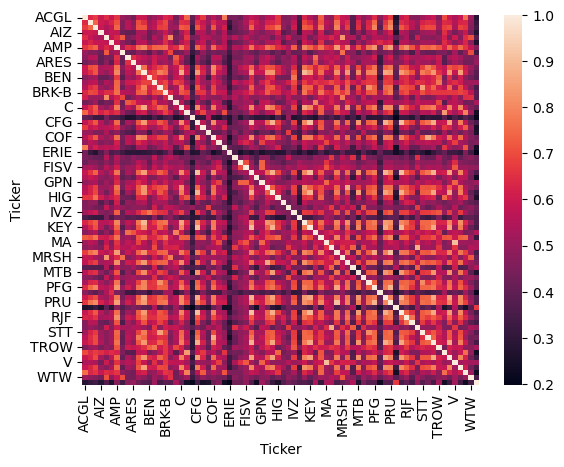

In [3]:
import seaborn as sns
sns.heatmap(returns.corr())

### Standardize + PCA Run

In [4]:
standardized_df = get_standardize_ret(returns)
pca = run_pca(standardized_df)
pc1_weights = pca.components_[0]

### Pick k

In [5]:
import numpy as np
cum_sum = np.cumsum(pca.explained_variance_ratio_)
k = np.argmax(cum_sum >= 0.6) + 1
print(k, cum_sum[:5]) 

2 [0.56162341 0.62726518 0.67108329 0.69093409 0.7081751 ]


Above component 1 alone explains 56%

This explains:
1. One dominant Component explaining >50% variance indicates string market factor

2. This matches expectation of single financials - stocks move together a lot

3. Variance added by component 2 onwards is small (~5-6% each) explaining diminishing returns

### Extract PC1 (*and Sanity Check*)

In [6]:
pc1_weights = pca.components_[0]
pc1_series = pd.Series(pc1_weights, index=returns.columns)
print(pc1_series.sort_values())

Ticker
ERIE    0.067464
CBOE    0.067818
XYZ     0.079564
JKHY    0.080074
PYPL    0.081013
          ...   
MET     0.135548
JPM     0.135823
BAC     0.136653
PRU     0.138634
AMP     0.140277
Length: 74, dtype: float64


### Build Signal

count: 124467
mean: -0.0
std: 0.952
% |s| > 1.25: 19.53
% |s| > 2: 2.53


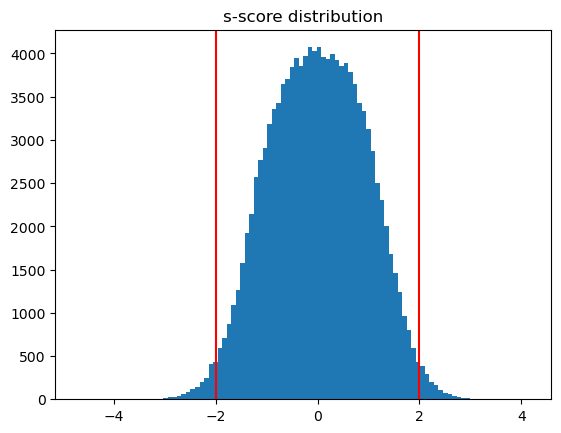

average pass rate: 0.989
min: 0.892 max: 1.0


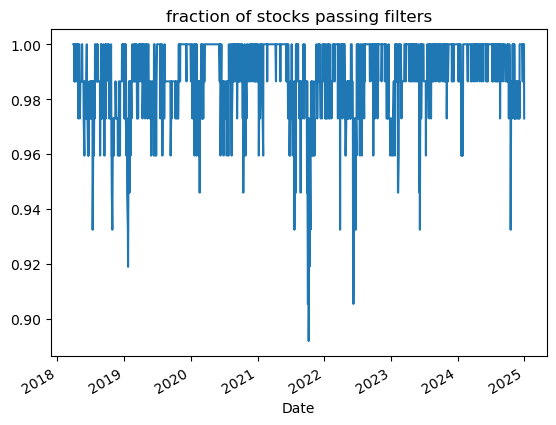

JPM b: 0.839 kappa: 44.4 s-score: 0.63


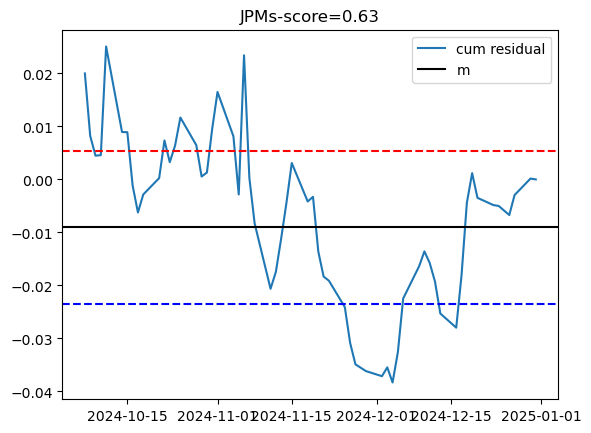

GS b: 0.845 kappa: 42.5 s-score: 0.43


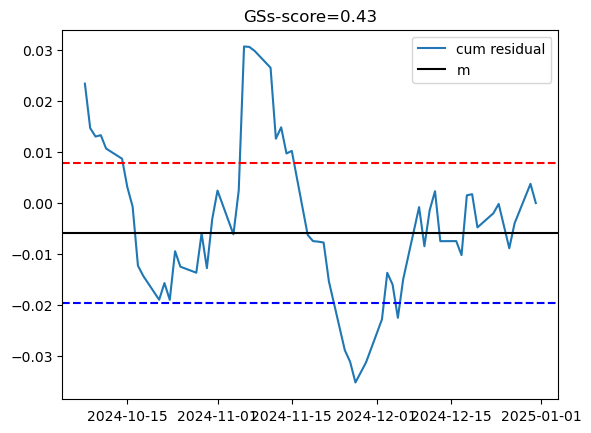

In [7]:
signals = build_signals(returns, window=60, k=1)
signals.to_csv("signals.csv")

check_distribution(signals)
check_pass_rate(returns, signals, window=60)
check_ticker(returns, 'JPM', t=len(returns) - 1)
check_ticker(returns, 'GS', t=len(returns) - 1)

### Backtest

In [8]:
signal = build_signals(returns)

In [9]:
w, gross, net, turnover, equity = run_backtest(returns, signal, cost_bps=5)
get_metrics(net, turnover)
cost_check(returns, signal)

sharpe: 0.44
annual returns: 0.021
annual vol: 0.048
max drawdown: -0.098
annual turnover: 19.1
hit rate: 0.518
0 bps -> sharpe 0.64
5 bps -> sharpe 0.44
10 bps -> sharpe 0.24


### Beta Check

In [10]:
def sh(x):
    return np.sqrt(252) * x.mean() / x.std()

mkt = returns.mean(axis=1)
beta = np.cov(net, mkt)[0, 1]/np.var(mkt, ddof=1)
resid = net - beta * mkt

print('avg |net exposure|:', round(w.sum(axis=1).abs().mean(), 4))
print('beta:', round(beta, 3))
print('corr with market:', round(net.corr(mkt), 3))
print('sharpe net:', round(sh(net), 2))
print('sharpe after removing market:', round(sh(resid), 2))
print('resid 2018 - 2021:', round(sh(resid['2018':'2021']), 2))
print('resid 2022 - 2024:', round(sh(resid['2022':'2024']), 2))


avg |net exposure|: 0.1046
beta: 0.119
corr with market: 0.595
sharpe net: 0.44
sharpe after removing market: 0.03
resid 2018 - 2021: 0.36
resid 2022 - 2024: -0.44
